In [1]:
%pip install -q joblib scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
)

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "breast_cancer.csv")
datos = datos.drop(columns=[c for c in datos.columns if c.startswith("Unnamed") or c == "id"])
datos["diagnosis"] = datos["diagnosis"].map({"M": 1, "B": 0})
datos.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
x = datos.drop(columns=["diagnosis"])
y = datos["diagnosis"]

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

validacion = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Entrenamiento: {x_entrena.shape[0]} casos | Prueba: {x_prueba.shape[0]} casos")

Entrenamiento: 455 casos | Prueba: 114 casos


In [4]:
pipeline = Pipeline([
    ("escala", StandardScaler()),
    ("logistica", LogisticRegression(max_iter=5000, random_state=42)),
])

rejilla = {
    "logistica__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logistica__class_weight": [None, "balanced"],
}

busqueda = GridSearchCV(pipeline, rejilla, cv=validacion, scoring="f1", n_jobs=-1)
busqueda.fit(x_entrena, y_entrena)

print("Mejores hiperparametros:", busqueda.best_params_)
print("Mejor F1 (CV, train):", round(busqueda.best_score_, 3))

modelo_final = busqueda.best_estimator_
pred_final = modelo_final.predict(x_prueba)
prob_final = modelo_final.predict_proba(x_prueba)[:, 1]

Mejores hiperparametros: {'logistica__C': 0.1, 'logistica__class_weight': 'balanced'}
Mejor F1 (CV, train): 0.962


In [5]:
metricas = {
    "Accuracy": accuracy_score(y_prueba, pred_final),
    "Precision": precision_score(y_prueba, pred_final),
    "Recall": recall_score(y_prueba, pred_final),
    "F1": f1_score(y_prueba, pred_final),
    "ROC-AUC": roc_auc_score(y_prueba, prob_final),
}
resultados = pd.DataFrame([metricas]).round(3)
print(classification_report(y_prueba, pred_final, target_names=["Benigno", "Maligno"]))
resultados

              precision    recall  f1-score   support

     Benigno       0.99      1.00      0.99        72
     Maligno       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.991,1.0,0.976,0.988,0.998


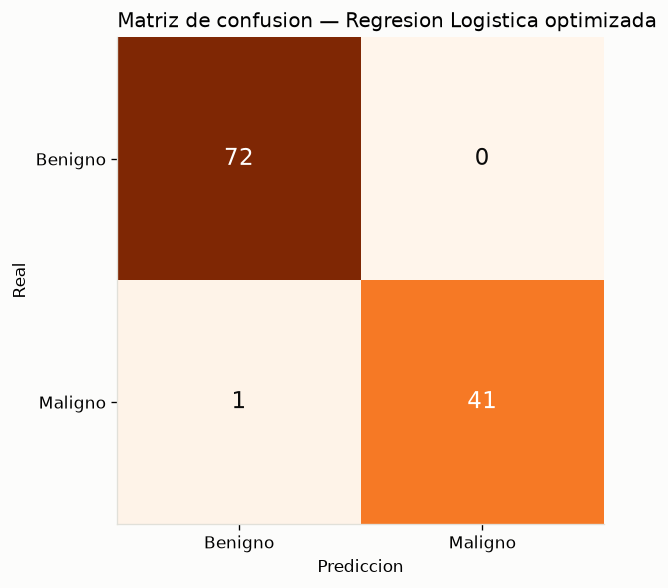

In [6]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

cm = confusion_matrix(y_prueba, pred_final)
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=120)
ax.imshow(cm, cmap="Oranges")
etiquetas = ["Benigno", "Maligno"]
ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas)
ax.set_xlabel("Prediccion"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusion — Regresion Logistica optimizada", loc="left")
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "#0b0b0b"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)
fig.tight_layout()
fig.savefig(ruta / "figures" / "de_matriz_confusion.png", facecolor=SURFACE)
plt.show()

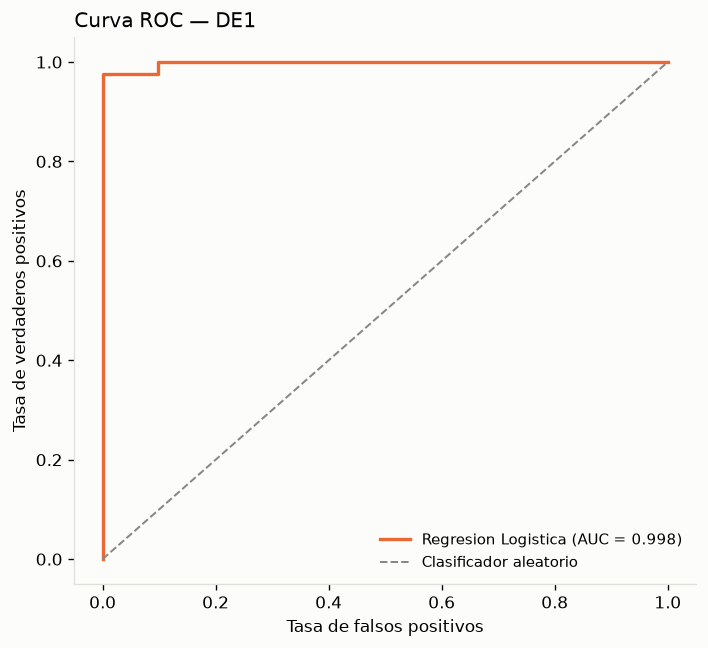

In [7]:
fpr, tpr, _ = roc_curve(y_prueba, prob_final)
auc = roc_auc_score(y_prueba, prob_final)

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=120)
ax.plot(fpr, tpr, color=ORANGE, linewidth=2, label=f"Regresion Logistica (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1.2, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — DE1", loc="left")
ax.legend(frameon=False, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(ruta / "figures" / "de_curva_roc.png", facecolor=SURFACE)
plt.show()

In [8]:
joblib.dump(modelo_final, ruta / "models" / "de_logistica_breast_cancer.joblib")
print("Modelo guardado en la carpeta models/")

Modelo guardado en la carpeta models/
